<a href="https://colab.research.google.com/github/Idighekere/pepper-bacterial-spot-detector-CO11/blob/main/notebooks/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Package Import and Setup

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
import shutil
import random

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix)


### Dataset Import


Import dataset directly from

In [4]:
!pip install kaggle

In [5]:
import kagglehub

path = kagglehub.dataset_download("zienabesam/pepper-belly-crop-plantvillage-ds")
print("Downloaded to:", path)
print("Folders:", os.listdir(path))

100%|██████████| 41.0M/41.0M [00:02<00:00, 15.7MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/zienabesam/pepper-belly-crop-plantvillage-ds/versions/1
Folders: ['Pepper Belly Crop DS']


Setting Seeds to ensure reproducibility

In [7]:
SEED = 11
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to : {SEED}')

TensorFlow version : 2.20.0
Random seed set to : 11


Creating the results folder to store exports of charts and graphs

In [9]:
results_dir = "results/"
if not os.path.exists(results_dir):
  os.makedirs(results_dir, exist_ok=True)

## Data Preprocessing

Organize the images into the `train (70%)`, `test(15%)` and `validation (15%)`

In [11]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SRC = os.path.join(path, "Pepper Belly Crop DS")
DST = Path("datasets")

CLASS_MAP = {
    "Pepper,_bell___Bacterial_spot": "Bacterial_Spot",
    "Pepper,_bell___healthy": "Healthy",
}

for old_name, new_name in CLASS_MAP.items():
    src_dir = os.path.join(SRC, old_name)
    images = [f for f in os.listdir(src_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    for split_name, file_list in [
        ("train", images[:n_train]),
        ("val", images[n_train:n_train + n_val]),
        ("test", images[n_train + n_val:]),
    ]:
        dst_dir = os.path.join(DST, split_name, new_name)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in file_list:
            shutil.copy2(os.path.join(src_dir, fname),
                         os.path.join(dst_dir, fname))
    print(f"{new_name}: {n} images split")

print("Done — datasets/ ready")

Bacterial_Spot: 997 images split
Healthy: 1478 images split
Done — datasets/ ready


### Configuring  datasets path

In [15]:
BASE_DIR = Path("datasets")
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'

### Setting Global Hyperparameters

In [12]:
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 64
EPOCHS = 50 # EarlyStopping will stop earlier when converged
LR = 1e-3 # Initial learning rate for the CNN from scratch

print(f'Image size : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size : 128 x 128
Batch size : 64
Max epochs : 50
Learning rate: 0.001


#### Loading Datasets

In [16]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
  train_dir,image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
  batch_size=BATCH_SIZE,seed=SEED, shuffle=True,
)

Found 1731 files belonging to 2 classes.


In [17]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
  val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
  batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

Found 370 files belonging to 2 classes.


In [18]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
  test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
  batch_size=BATCH_SIZE, seed=SEED,shuffle=False,
)

Found 374 files belonging to 2 classes.


Get the classnames and nmber of clasess. The class names are auto inferred from the subdirectory names  in the training directory

In [19]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (2): ['Bacterial_Spot', 'Healthy']


Visulizing the first 16 images and their labels

In [20]:
# Capture one fixed batch so the visualisation is stable across re-runs
for images, labels in train_dataset.take(1):
  fixed_images = images.numpy()
  fixed_labels = labels.numpy()

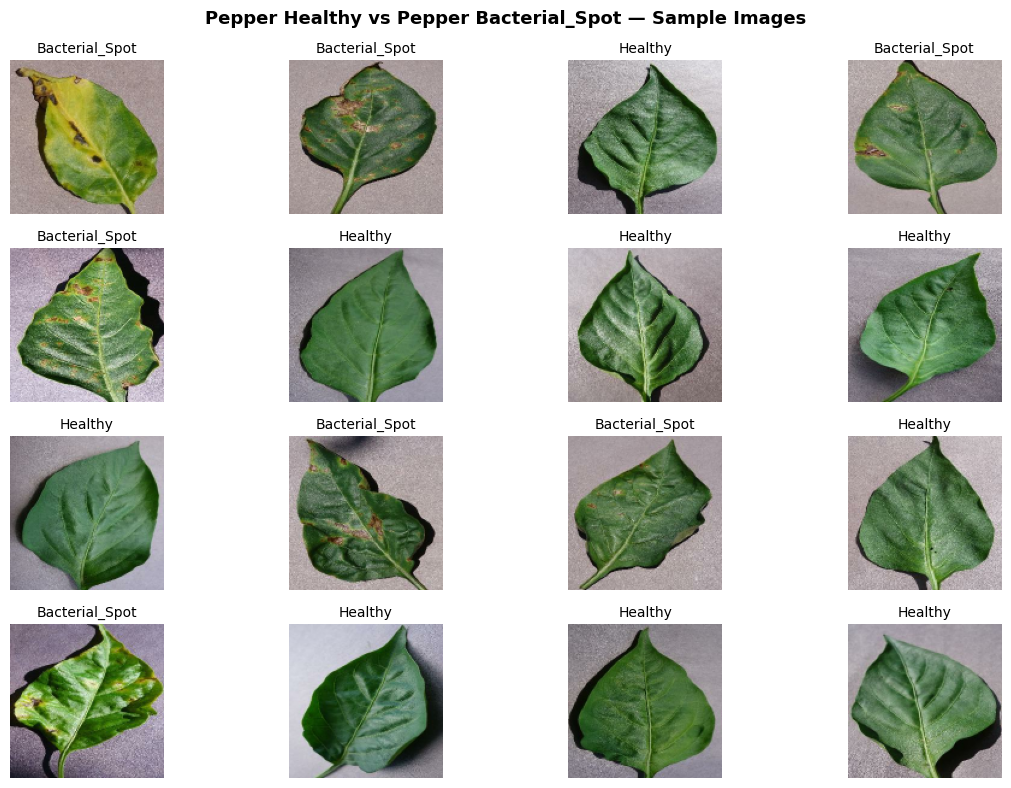

In [21]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
  ax = plt.subplot(4, 4, i + 1)
  plt.imshow(fixed_images[i].astype('uint8'))
  plt.title(class_names[fixed_labels[i]], fontsize=10)
  plt.axis('off')

plt.suptitle('Pepper Healthy vs Pepper Bacterial_Spot — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/lab10_samples.png', dpi=120, bbox_inches='tight')
plt.show()

### Data Pipeline Optimization

- `.cache()` stores batches in RAM after the first epoch, eliminating repeated disk reads
- `.shuffle(1000)` randomises the order of samples so the model doesn't learn file ordering
-  `.prefetch(AUTOTUNE)` overlaps CPU preprocessing with GPU training, eliminating GPU
starvation

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE))
val_dataset = (val_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))

print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


#### Data Augmentation

Data augmentation synthetically expands the training
set by randomly transforming each image on the fly.

In [23]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

Visualizing augmentation effects on one image

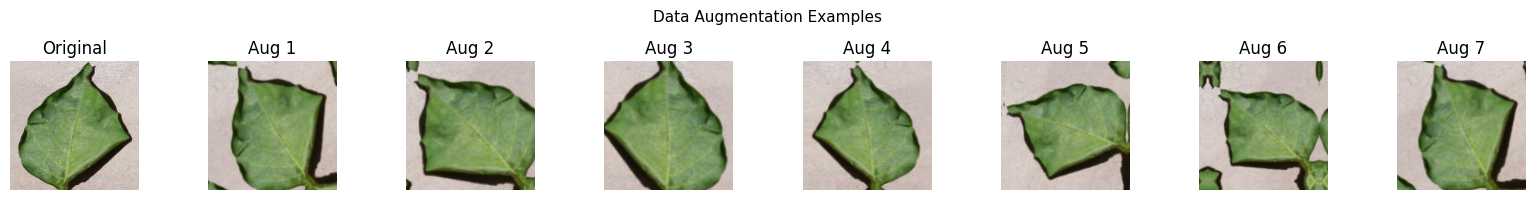

In [25]:
for images, _ in train_dataset.take(1):
  sample = images[0:1] # shape (1, 224, 224, 3)
  break


fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
  aug_img = data_augmentation(sample,
  training=True)[0].numpy().astype('uint8')
  axes[i].imshow(aug_img)
  axes[i].set_title(f'Aug {i}')
  axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig('results/augmented_sample.png', dpi=120, bbox_inches='tight')
plt.show()

## Define Callback and Utilties



Create a folder `models` to sabe teh model files

In [28]:
os.makedirs('models', exist_ok=True)


In [29]:


def make_callbacks(name):
  """Return a fresh set of callbacks for each model."""

  return [
  tf.keras.callbacks.ModelCheckpoint(
    filepath=f'models/{name}_best.keras',
    monitor='val_accuracy', save_best_only=True,
  ),

  tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8,
    restore_best_weights=True, verbose=1,
  ),

  tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.3,
    patience=4, min_lr=1e-7, verbose=1
  ),
  ]

In [30]:
def plot_learning_curves(history, title='Learning Curves'):
  """Plot accuracy and loss curves side-by-side."""

  acc  = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss  = history.history['loss']
  val_loss = history.history['val_loss']
  epochs_range = range(len(acc))

  plt.figure(figsize=(14, 5))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
  plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
  plt.legend()
  plt.title(f'{title} — Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.grid(alpha=0.3)

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
  plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
  plt.legend()
  plt.title(f'{title} — Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.grid(alpha=0.3)

  plt.tight_layout()
  plt.savefig(f'results/lab10_{title.lower().replace(" ",  "_")}_curves.png', dpi=120, bbox_inches='tight')


In [40]:
def evaluate_model(model, dataset, class_names, title='Model',
results_dir='./'):
    """Evaluate a multiclass classification model."""

    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)
    print(f"\n{title}")

    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred,
    average="weighted"):.4f}')
    print(f'Recall : {recall_score(y_true, y_pred,  average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names,
    digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True,fmt='',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 9, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(
        f'results/lab10_{title.lower().replace(" ",
        "_")}_confusion.png', dpi=120, bbox_inches='tight')

    plt.show()
    return accuracy_score(y_true, y_pred)
    print('Callbacks and utility functions defined.')

## Model Building

In [32]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
OUTPUTS = num_classes

def build_custom_cnn(input_shape, augmentation):
    """
    A three-block CNN built entirely from scratch.
    Filters double each block (32 >> 64 >> 128) following a standard design
    pattern.
    Augmentation is embedded inside the model so it runs automatically during
    training.
    """
    inputs = tf.keras.Input(shape=input_shape)


    # Augmentation (active only during training)
    x = augmentation(inputs)
    # Normalise pixel values from [0, 255] to [0, 1]
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Binary output: sigmoid → probability of class 1 (dogs)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='custom_cnn')

cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

### Compile Model

In [33]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

### Train Model

In [36]:
cnn_history = cnn_model.fit(train_dataset, validation_data=val_dataset,epochs=EPOCHS,
callbacks=make_callbacks('custom_cnn'), verbose=1)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - accuracy: 0.8769 - loss: 0.3028 - val_accuracy: 0.5973 - val_loss: 0.6813 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.9139 - loss: 0.2107 - val_accuracy: 0.6027 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 240ms/step - accuracy: 0.9544 - loss: 0.1172 - val_accuracy: 0.6351 - val_loss: 0.8302 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.9827 - loss: 0.0557 - val_accuracy: 0.6135 - val_loss: 1.0059 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.9838 - loss: 0.0401 - val_accuracy: 0.5973 - val_loss: 1.9663 - learning_rate: 0.0010
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.9850 - loss: 0.0372 - val_accuracy: 0.7243 - val_loss: 0.5796 - learning_rate: 0.0010
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.9925 - loss: 0.0216 -

### Evaluate Model (Validation Set)

In [37]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 0.0912
val_accuracy: 0.9946


### Visualize

NameError: name 'p' is not defined

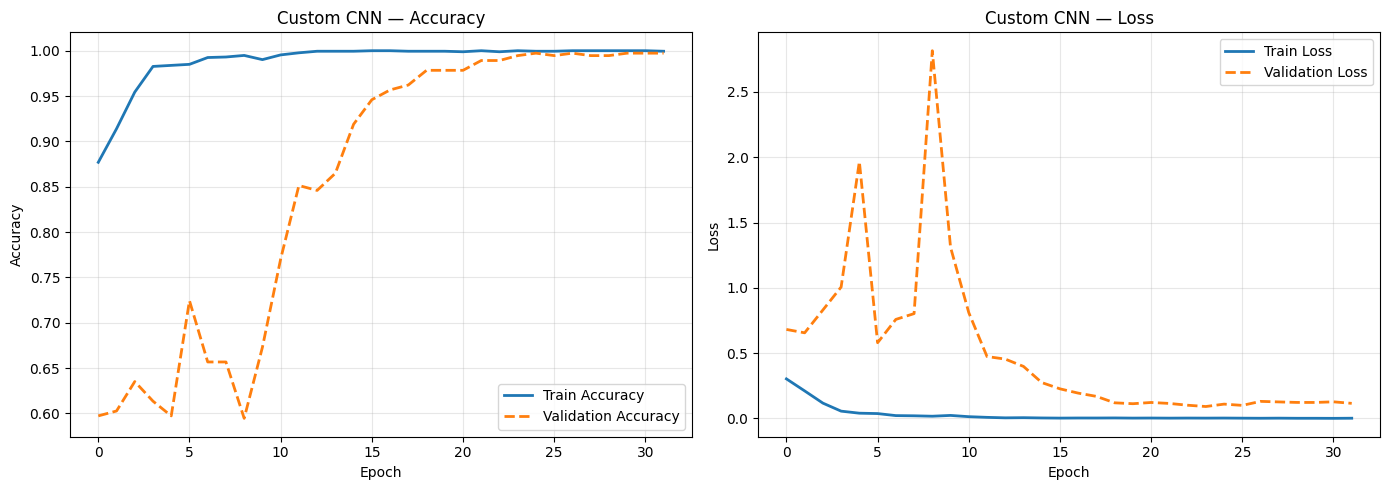

In [41]:
plot_learning_curves(cnn_history, 'Custom CNN')

### Evaulaute Model (Test Set)


Custom CNN
Accuracy : 0.9947
Precision : 0.9947
Recall : 0.9947
F1-Score : 0.9947

Classification Report:
                precision    recall  f1-score   support

Bacterial_Spot     0.9934    0.9934    0.9934       151
       Healthy     0.9955    0.9955    0.9955       223

      accuracy                         0.9947       374
     macro avg     0.9944    0.9944    0.9944       374
  weighted avg     0.9947    0.9947    0.9947       374



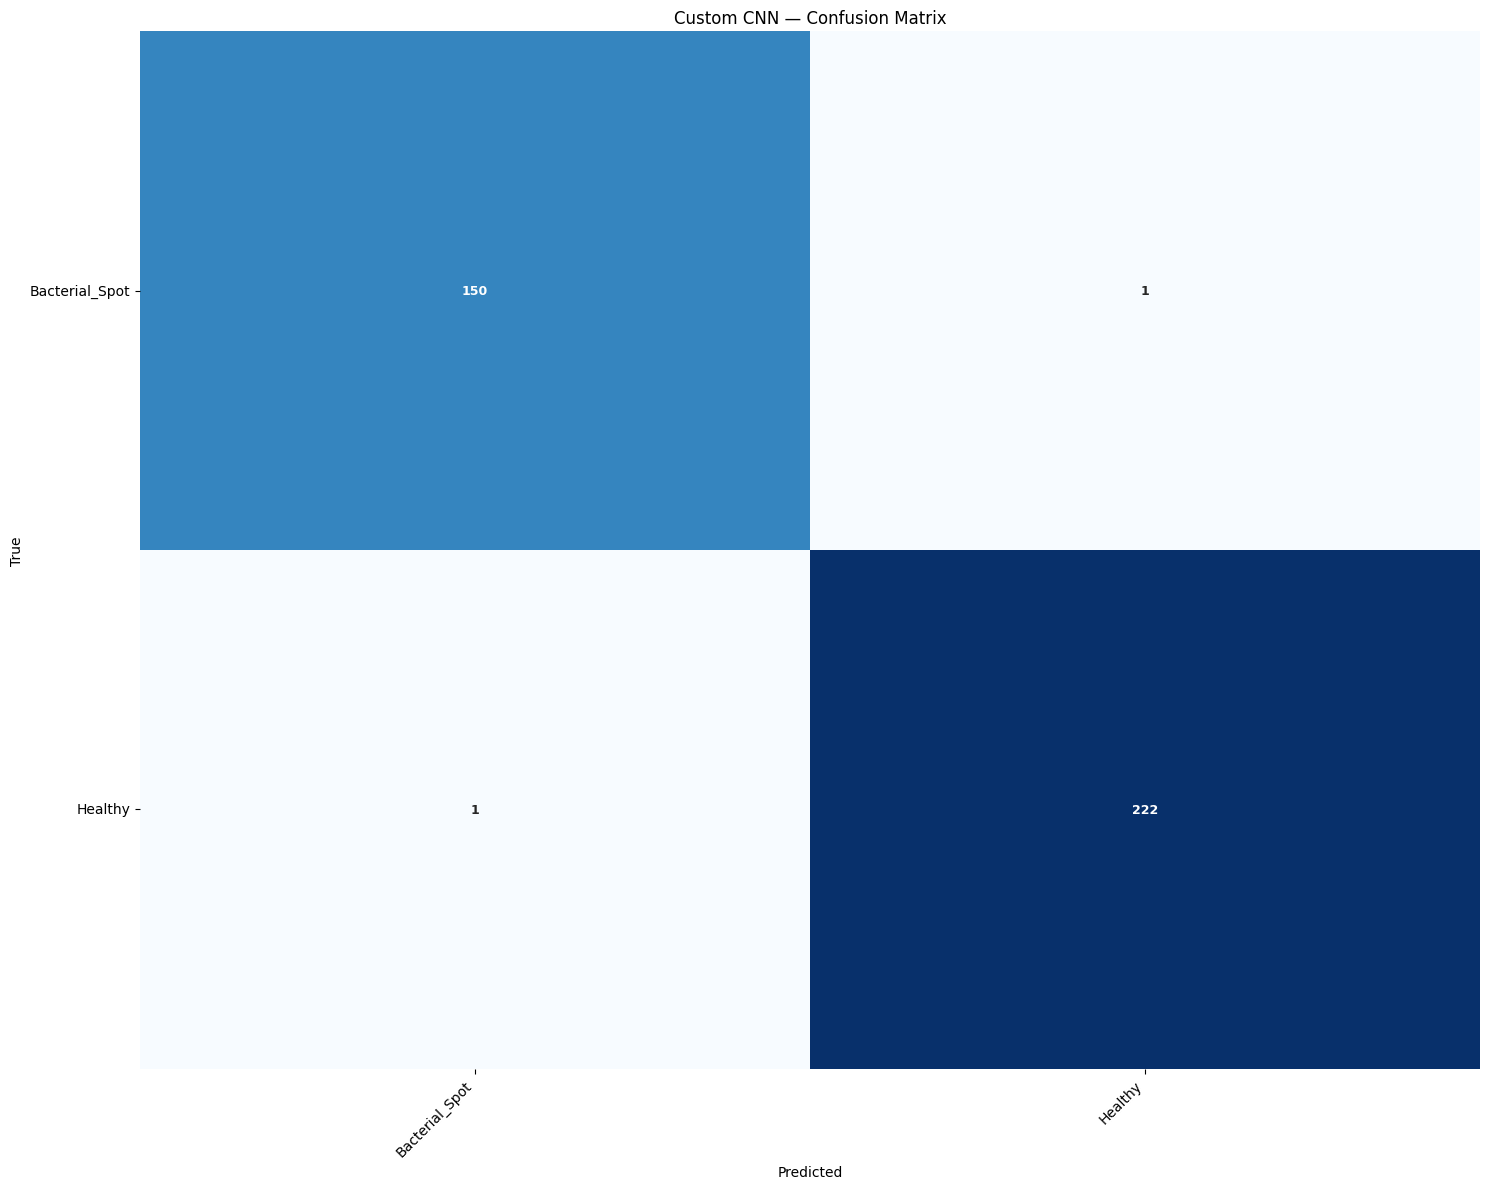

In [42]:
cnn_test_acc = evaluate_model(cnn_model, test_dataset,class_names, 'Custom CNN')

### Get Resulsts

In [43]:
results = {
'Custom CNN': {'acc': cnn_test_acc, 'params': cnn_model.count_params()},}

print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
  print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.9947        322,338


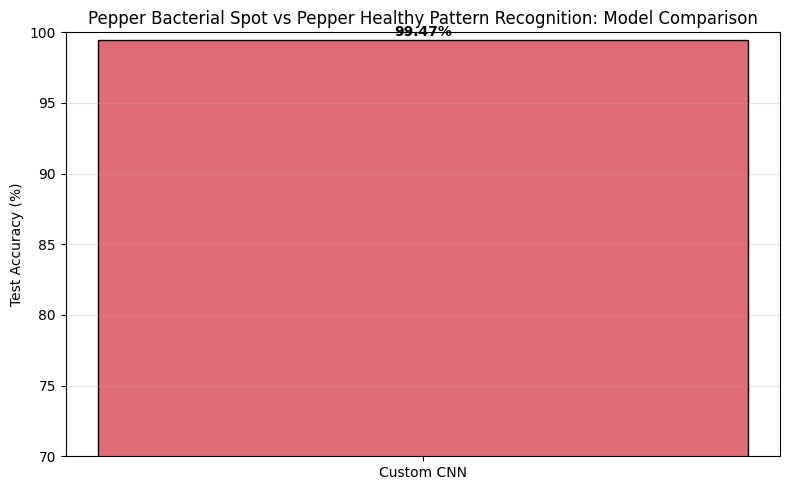

In [44]:
labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]
colors = ['#e06c75', '#61afef']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(70, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Pepper Bacterial Spot vs Pepper Healthy Pattern Recognition: Model Comparison')
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
  ax.text(bar.get_x() + bar.get_width() / 2,
  bar.get_height() + 0.3,
  f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Test Model

In [45]:
def predict_image(img_path, models_dict, class_names, image_size=(224,
224)):
  """Load an image file and classify it with each model in models_dict."""
  img = tf.keras.utils.load_img(img_path, target_size=image_size)
  img_array = tf.keras.utils.img_to_array(img) # [0, 255] float32
  img_array = np.expand_dims(img_array, axis=0)   # (1, H, W, 3)

  plt.figure(figsize=(3, 3))
  plt.imshow(img)
  plt.axis('off')
  plt.title('Input Image')
  plt.show()

  print(f'\nPredictions for: {img_path}')
  print('-' * 40)
  for name, mdl in models_dict.items():
    prob = mdl.predict(img_array, verbose=0)[0][0]
    label = class_names[int(prob >= 0.5)]
    print(f'{name:<25}: {label} (p={prob:.4f})')

Predict with an actuall image

In [ ]:
# Update path to an image you want to test
# predict_image(
# 'path/to/your/image.jpg',
# {'Custom CNN': cnn_model},
# class_names
# )

# Save Models

In [46]:
cnn_model.save('models/custom_cnn.keras')

print('Models saved:')
print(' models/custom_cnn.keras')


Models saved:
 models/custom_cnn.keras
